<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4p/blob/main/05_stan_1.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(stan-reglin1-notebook)=
# La percezione dell'inclinazione locale

## Preparazione del Notebook

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import arviz as az
import warnings
from cmdstanpy import cmdstan_path, CmdStanModel

/Users/corrado/opt/anaconda3/envs/stan_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
def scale_columns(dataframe, columns_to_scale):
    # Work on a copy to avoid modifying the original DataFrame
    df_scaled = dataframe.copy()
    for column in columns_to_scale:
        # Scale each specified column individually
        df_scaled[column] = stats.zscore(df_scaled[column])
    return df_scaled

Utilizzeremo il modello `linear_regression.stan` che può essere usato sia per la regressione bivariata sia per la regressione multipla. Il modello Stan assume che tutte le variabili, sia la $y$ sia le $X$ siano standardizzate. Sui parametri del modello ($\alpha$, $\beta$, $\sigma$) sono state imposte delle distribuzioni a priori debolmente informative.

In [4]:
stan_file = os.path.join('stan', 'def_model.stan')
with open(stan_file, 'r') as f:
    print(f.read())

data {
  int<lower=0> N;         // Numero di misurazioni
  vector[N] def;          // Valori di deformazione
}
parameters {
  vector<lower=0, upper=1>[N] s;       // Slant per ogni misurazione
  vector<lower=0, upper=1>[N] omega;   // Velocità di rotazione locale per ogni misurazione
  real<lower=0> sigma;
}
model {
  // Priori
  s ~ beta(1, 1);
  omega ~ beta(1, 1);
  
  // Likelihood
  for (i in 1:N) {
    def[i] ~ normal(s[i] * omega[i], sigma); // Assumendo una certa varianza sigma
  }
}



Compiliamo il modello.

In [5]:
model = CmdStanModel(stan_file=stan_file)
print(model)

CmdStanModel: name=def_model
	 stan_file=/Users/corrado/_repositories/ds4p/chapter_5/stan/def_model.stan
	 exe_file=/Users/corrado/_repositories/ds4p/chapter_5/stan/def_model
	 compiler_options=stanc_options={}, cpp_options={}


In [6]:
N = 100
sigma_degress = np.random.uniform(10, 80, size=N)
sigma_radians = np.deg2rad(sigma_degress)

omega_degrees_per_second = np.random.uniform(0, 180, size=N)
omega_radians_per_second = np.deg2rad(omega_degrees_per_second)

def_values = sigma_radians * omega_radians_per_second

noise_std_dev = 0.1

def_values_perturbed = def_values + np.random.normal(0, noise_std_dev, def_values.shape)

I dati devono essere contenuti in un dizionario. Nel caso presente, il dizionario `data` può essere creato nel modo seguente.

In [7]:
stan_data = {
    "N" : N,
    "def" : def_values_perturbed
}

Eseguiamo il campionamento MCMC.

In [8]:
fit = model.sample(data=stan_data)

04:34:30 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status





chain 1 |▉         | 00:00 Iteration:    1 / 2000 [  0%]  (Warmup)

chain 1 |█▎        | 00:00 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |██▎       | 00:00 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |███▏      | 00:00 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |████      | 00:01 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |█████     | 00:01 Iteration:  900 / 2000 [ 45%]  (Warmup)


chain 1 |██████▎   | 00:01 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |███████▎  | 00:01 Iteration: 1300 / 2000 [ 65%]  (Sampling)


chain 1 |████████▏ | 00:01 Iteration: 1500 / 2000 [ 75%]  (Sampling)


chain 1 |█████████ | 00:01 Iteration: 1700 / 2000 [ 85%]  (Sampling)


chain 1 |██████████| 00:02 Sampling completed                       
chain 2 |██████████| 00:02 Sampling completed                       
chain 3 |██████████| 00:02 Sampling completed                       
ch


04:34:33 - cmdstanpy - INFO - CmdStan done processing.
04:34:33 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'def_model.stan', line 17, column 4 to column 44)
Consider re-running with show_console=True if the above output is unclear!


Esaminiamo i risultati ottenuti.

In [9]:
print(fit.summary())

                  Mean      MCSE     StdDev          5%         50%  \
lp__       -480.709000  0.332513  11.266100 -499.946000 -480.083000   
s[1]          0.503172  0.003074   0.284225    0.052270    0.505054   
s[2]          0.513029  0.002997   0.290102    0.049899    0.528578   
s[3]          0.507042  0.003267   0.290573    0.055712    0.507152   
s[4]          0.501833  0.003202   0.281998    0.056235    0.501380   
...                ...       ...        ...         ...         ...   
omega[97]     0.508248  0.003087   0.290695    0.048610    0.512774   
omega[98]     0.566579  0.003232   0.279150    0.070278    0.599514   
omega[99]     0.545647  0.003409   0.289952    0.061027    0.568823   
omega[100]    0.500132  0.003123   0.282696    0.054051    0.499855   
sigma         1.376423  0.001069   0.100749    1.222190    1.370130   

                   95%        N_Eff      N_Eff/s     R_hat  
lp__       -463.063000  1147.960000   299.495000  1.004150  
s[1]          0.944890  8

In [10]:
print(fit.diagnose())

Processing csv files: /var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/tmpgfh2vb39/def_modelmia92i6n/def_model-20240328043430_1.csv, /var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/tmpgfh2vb39/def_modelmia92i6n/def_model-20240328043430_2.csv, /var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/tmpgfh2vb39/def_modelmia92i6n/def_model-20240328043430_3.csv, /var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/tmpgfh2vb39/def_modelmia92i6n/def_model-20240328043430_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Processing complete, no problems detected.



L'oggetto `fit` generato da `cmdstanpy` appartiene alla classe `cmdstanpy.stanfit.mcmc.CmdStanMCMC`. Questo oggetto è funzionalmente equivalente a un oggetto della classe `InferenceData`, permettendo quindi la sua manipolazione tramite le funzioni fornite da ArviZ.

In [11]:
az.summary(fit, var_names=(["s", "omega", "sigma"]), hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
s[0],0.503,0.284,0.026,0.968,0.003,0.003,8599.0,2601.0,1.00
s[1],0.513,0.290,0.037,0.983,0.003,0.002,9710.0,2597.0,1.00
s[2],0.507,0.291,0.056,1.000,0.003,0.003,8540.0,2630.0,1.00
s[3],0.502,0.282,0.015,0.953,0.003,0.003,8145.0,2823.0,1.00
s[4],0.532,0.285,0.065,1.000,0.003,0.003,8030.0,2478.0,1.00
...,...,...,...,...,...,...,...,...,...
omega[96],0.508,0.291,0.047,0.998,0.003,0.003,9034.0,2688.0,1.00
omega[97],0.567,0.279,0.070,1.000,0.003,0.002,7845.0,2334.0,1.00
omega[98],0.546,0.290,0.061,1.000,0.003,0.002,7825.0,2477.0,1.01
omega[99],0.500,0.283,0.054,1.000,0.003,0.003,7864.0,2483.0,1.00


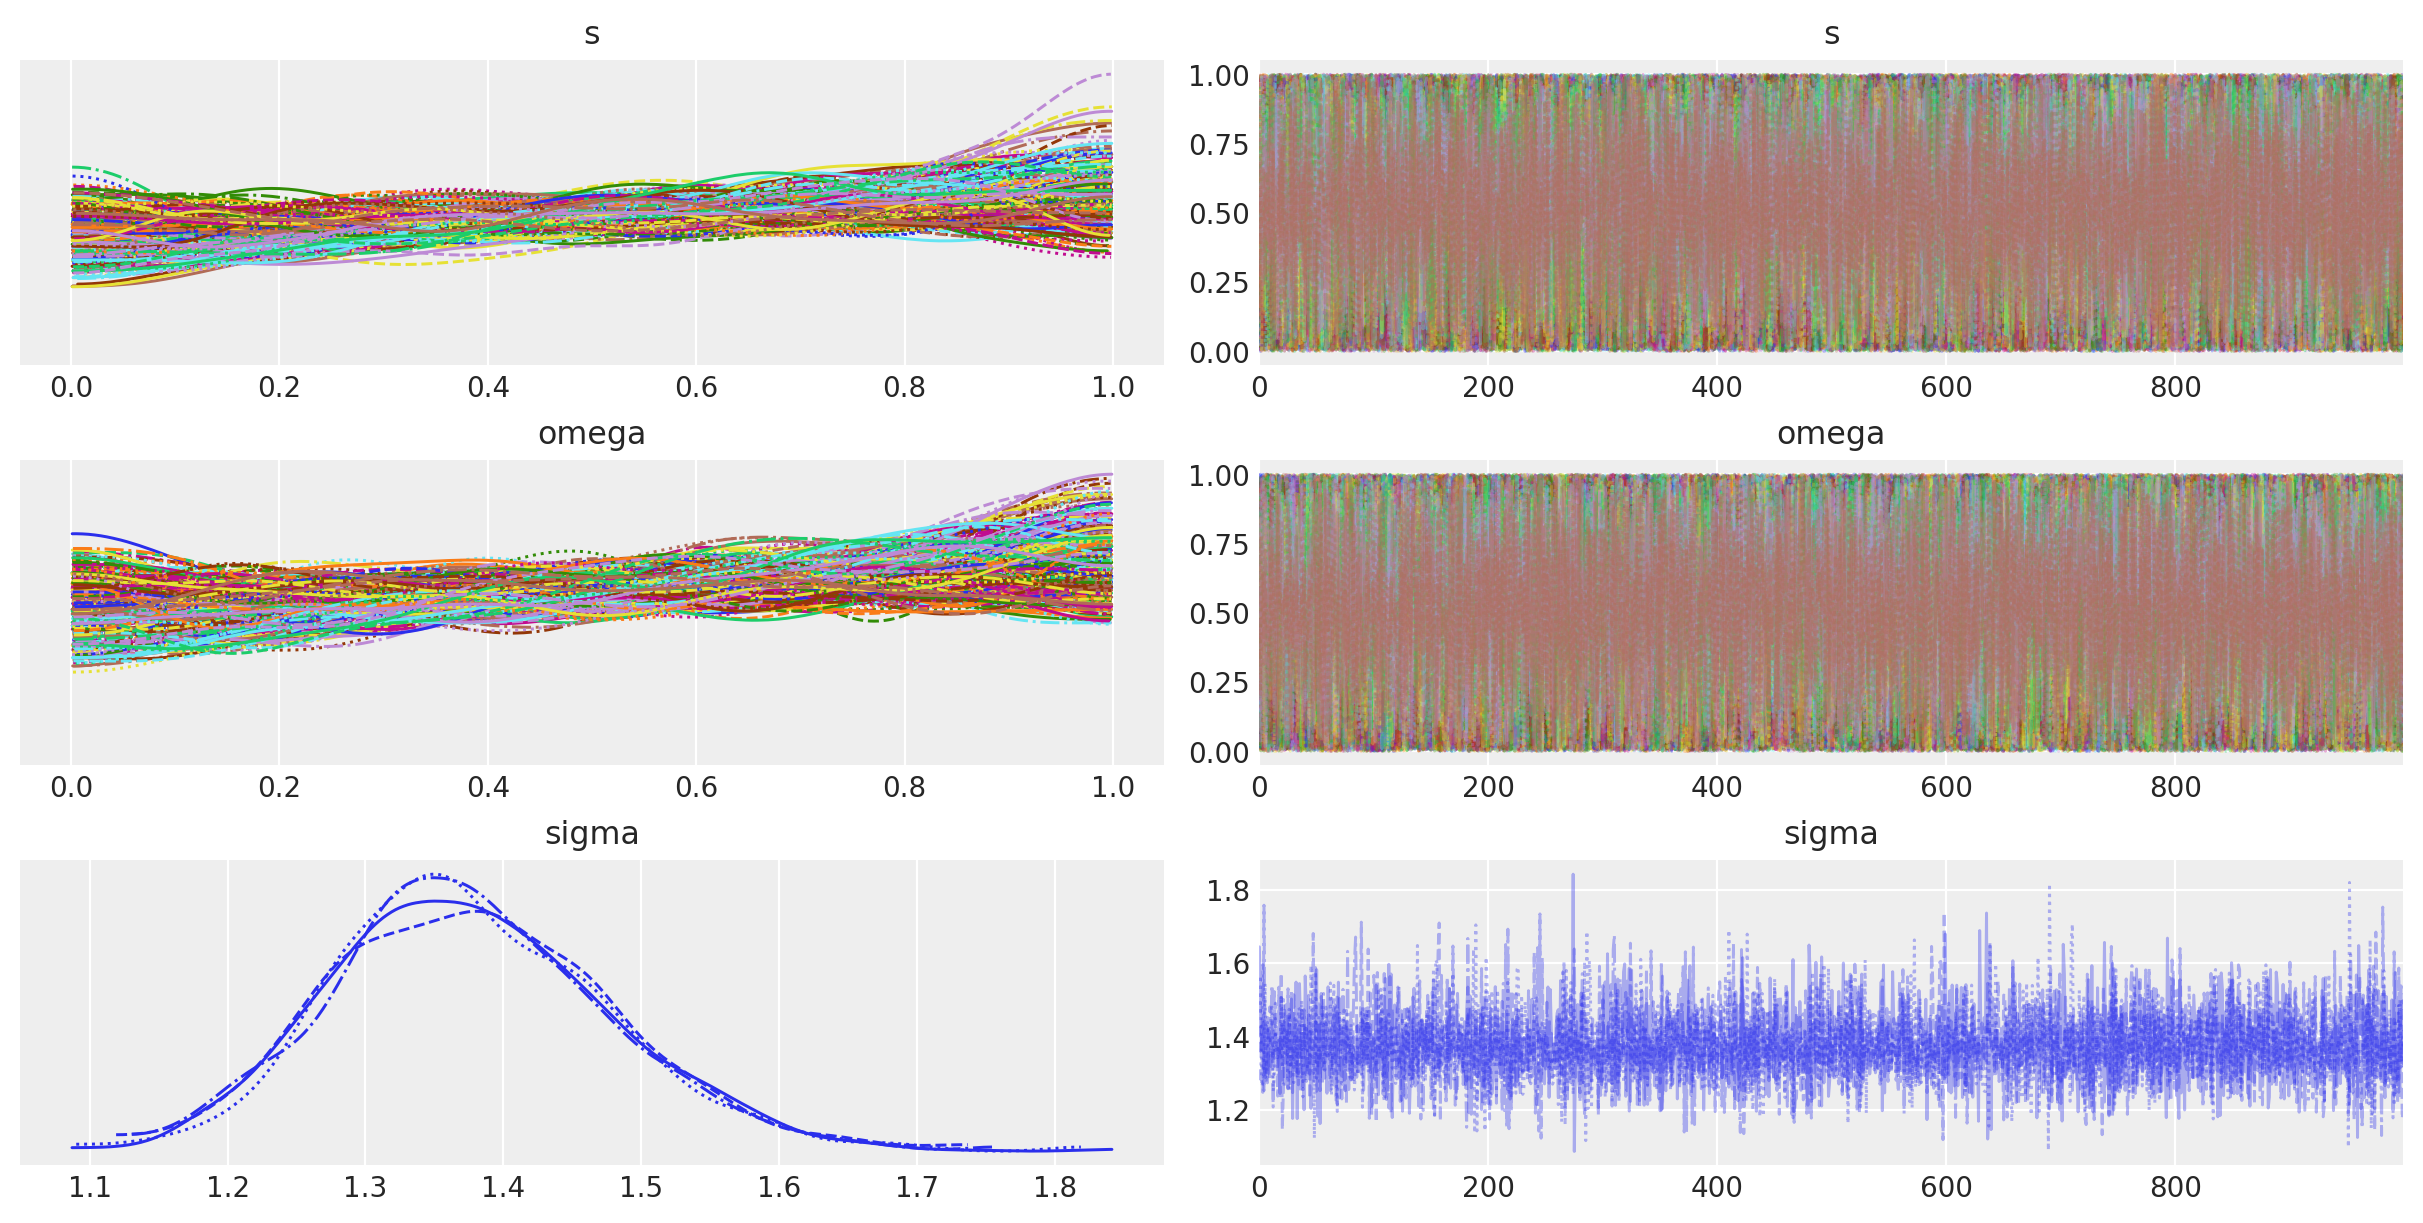

In [12]:
_ = az.plot_trace(fit, var_names=(["s", "omega", "sigma"]))

In [13]:
s_samples = fit.stan_variable('s')
omega_samples = fit.stan_variable('omega')

In [14]:
sqrt_def = np.sqrt(def_values)

/var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/ipykernel_33397/3780119552.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


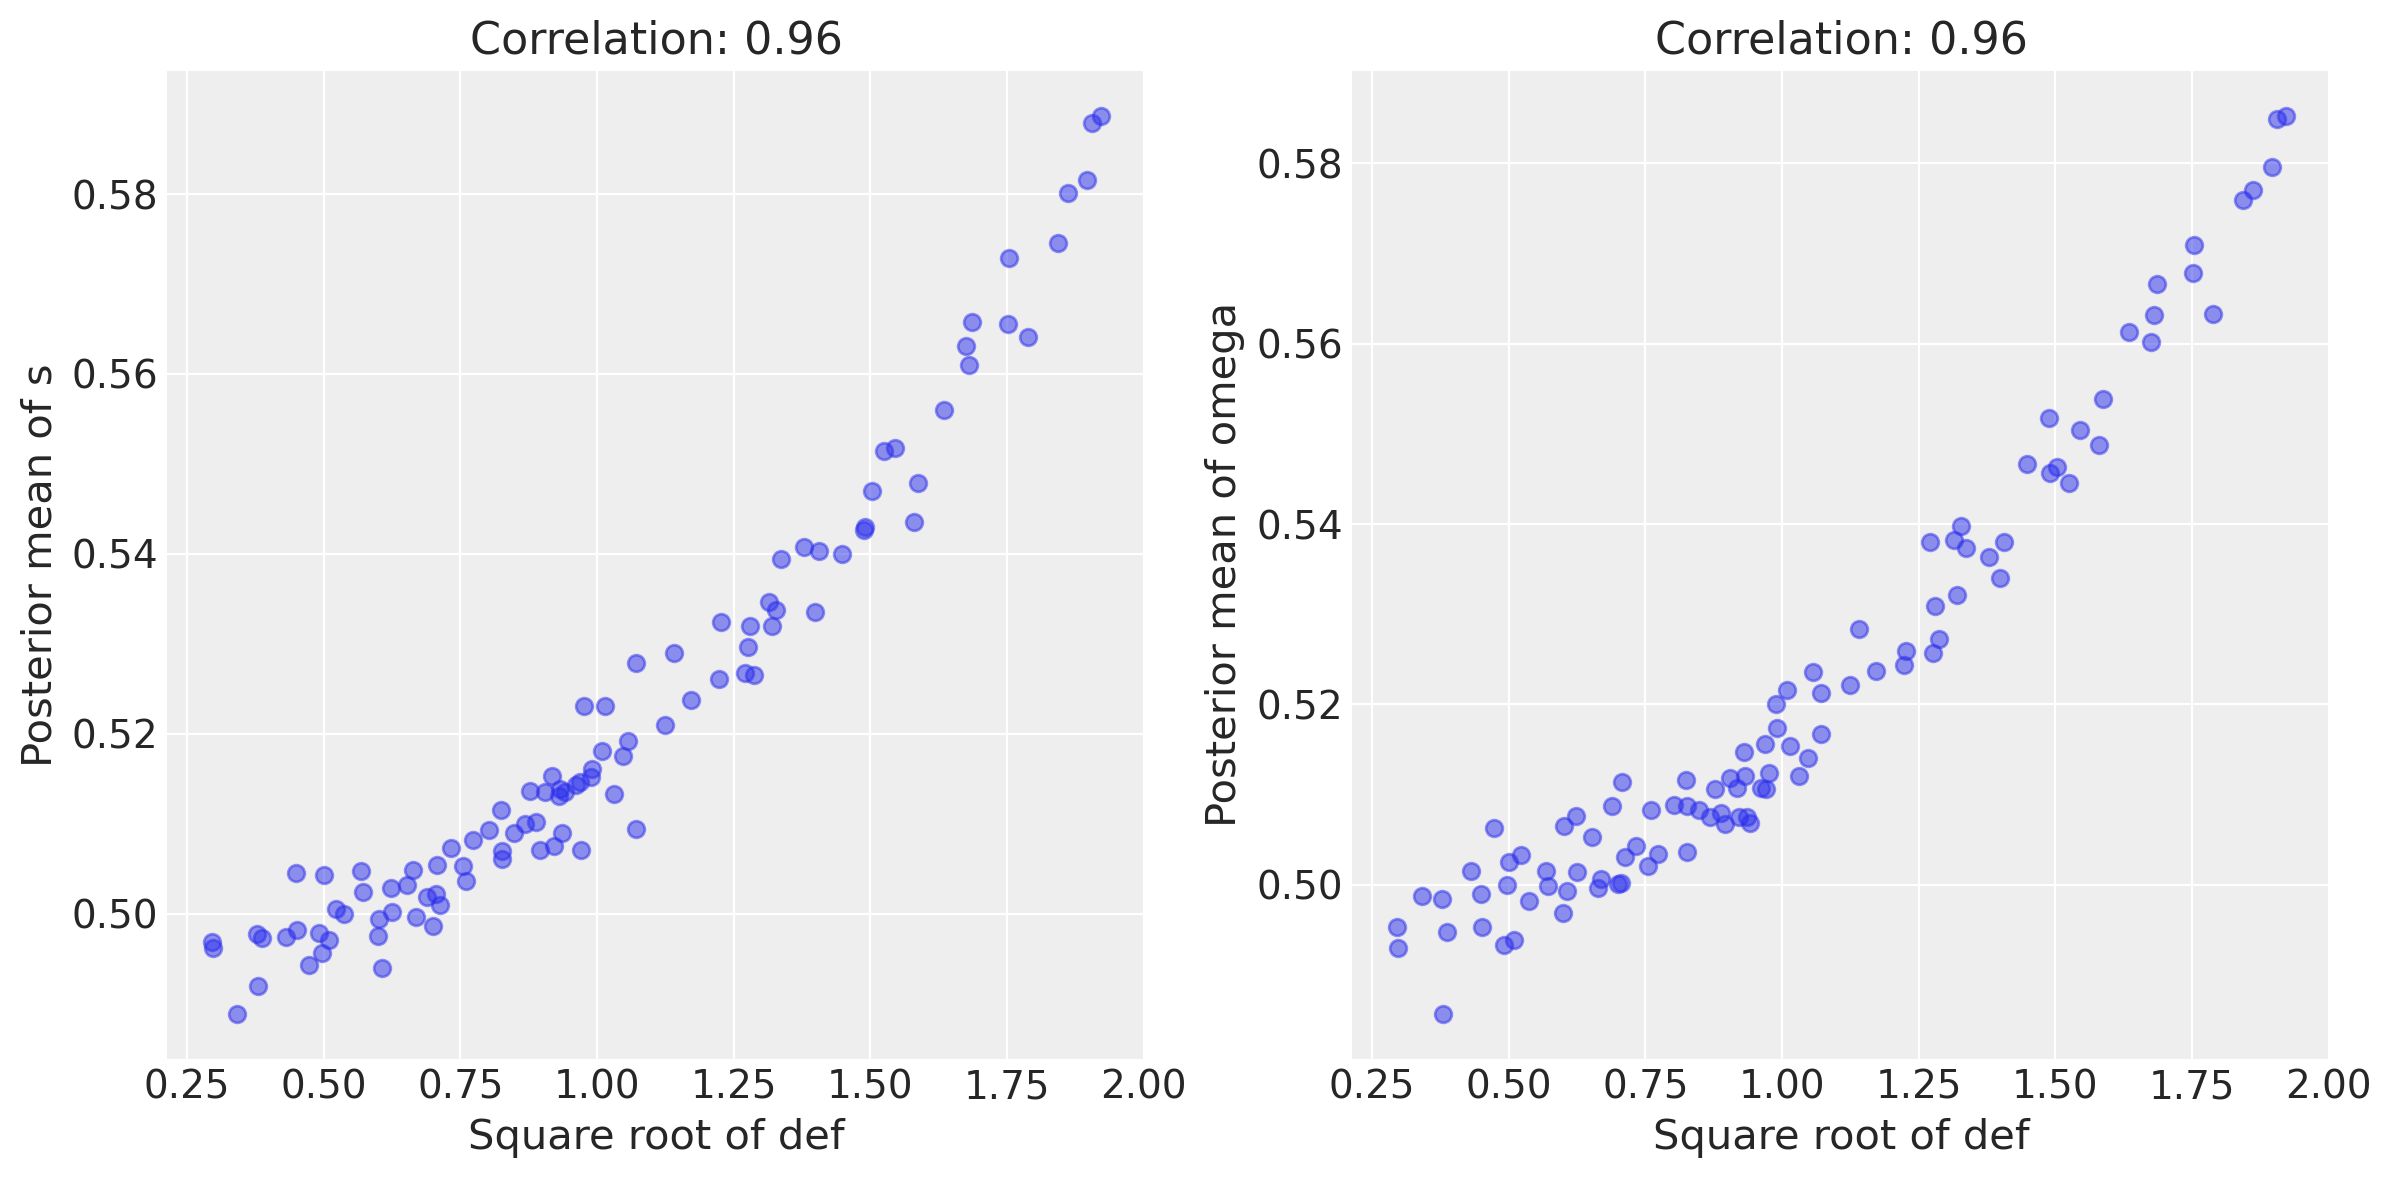

In [15]:
import matplotlib.pyplot as plt

# Calculate the posterior means
s_mean = np.mean(s_samples, axis=0)
omega_mean = np.mean(omega_samples, axis=0)

# Calculate correlations
cor_s = np.corrcoef(sqrt_def, s_mean)[0, 1]
cor_omega = np.corrcoef(sqrt_def, omega_mean)[0, 1]

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(sqrt_def, s_mean, alpha=0.5)
plt.xlabel('Square root of def')
plt.ylabel('Posterior mean of s')
plt.title(f'Correlation: {cor_s:.2f}')

plt.subplot(1, 2, 2)
plt.scatter(sqrt_def, omega_mean, alpha=0.5)
plt.xlabel('Square root of def')
plt.ylabel('Posterior mean of omega')
plt.title(f'Correlation: {cor_omega:.2f}')

plt.tight_layout()
plt.show()
